# Step 5: Feature Selection
### DI 501 Term Project | Eda Yilmaz

**Goal:**
Apply two systematic feature selection approaches to identify which climate stress features to retain for the RQ2 machine learning model.

**Starting features (from Step 3):**
- `heat_stress_days` — days with tmax > 30°C in JJA
- `cwb_deficit_gs` — cumulative crop water balance deficit, April–September
- `tavg_jja` — mean summer temperature, JJA
- `prec_gs` — total growing season precipitation, April–September

**Two approaches used:**
1. **Pearson Correlation Analysis** — identifies redundant feature pairs
2. **Variance Inflation Factor (VIF)** — quantifies multicollinearity severity

**Pre-processing:** StandardScaler normalization applied before modelling

---

## 1. Load Data & Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 120

FEATURES = ['heat_stress_days', 'cwb_deficit_gs', 'tavg_jja', 'prec_gs']
PANELS   = ['Mediterranean', 'Temperate', 'Continental']

df = pd.read_csv('./master_ml_dataset.csv').dropna(subset=FEATURES)

print(f'ML dataset loaded: {len(df):,} observations, {df["adm_id"].nunique()} regions')
print(f'Years: {df["harvest_year"].min()}–{df["harvest_year"].max()}')
print()
print('Observations per panel:')
print(df['panel'].value_counts().to_string())

ML dataset loaded: 10,662 observations, 671 regions
Years: 2001–2021

Observations per panel:
panel
Temperate        5851
Mediterranean    3304
Continental      1507


---
## 2. Approach 1 — Pearson Correlation Analysis

Pearson correlation measures linear relationships between features.
- |r| > 0.7 → high correlation → potential redundancy
- |r| < 0.5 → low correlation → features bring independent information

In [20]:
corr_matrix = df[FEATURES].corr()

print('Pearson Correlation Matrix:')
print()
print(corr_matrix.round(3).to_string())
print()
print('Pairs with |r| > 0.7 (high — potential redundancy):')
for i, f1 in enumerate(FEATURES):
    for j, f2 in enumerate(FEATURES):
        if i < j:
            r = corr_matrix.loc[f1, f2]
            flag = 'HIGH' if abs(r) > 0.7 else ('MODERATE' if abs(r) > 0.5 else 'LOW')
            print(f'  {f1} vs {f2}: r = {r:.3f} ({flag})')

Pearson Correlation Matrix:

                  heat_stress_days  cwb_deficit_gs  tavg_jja  prec_gs
heat_stress_days             1.000           0.821     0.870   -0.469
cwb_deficit_gs               0.821           1.000     0.857   -0.726
tavg_jja                     0.870           0.857     1.000   -0.482
prec_gs                     -0.469          -0.726    -0.482    1.000

Pairs with |r| > 0.7 (high — potential redundancy):
  heat_stress_days vs cwb_deficit_gs: r = 0.821 (HIGH)
  heat_stress_days vs tavg_jja: r = 0.870 (HIGH)
  heat_stress_days vs prec_gs: r = -0.469 (LOW)
  cwb_deficit_gs vs tavg_jja: r = 0.857 (HIGH)
  cwb_deficit_gs vs prec_gs: r = -0.726 (HIGH)
  tavg_jja vs prec_gs: r = -0.482 (LOW)


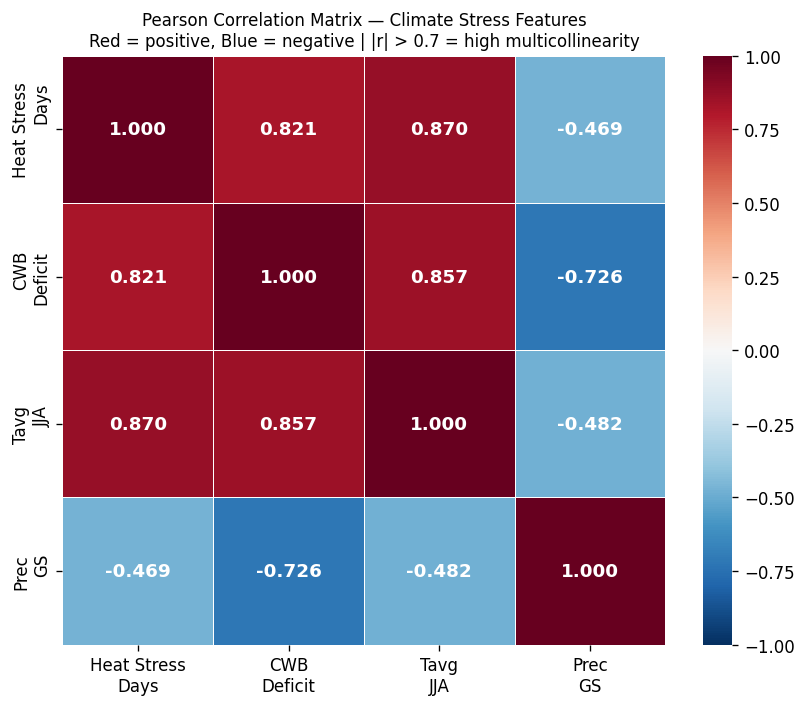

Saved: fig_correlation_matrix_step5.png


In [21]:
fig, ax = plt.subplots(figsize=(7, 6))

labels = ['Heat Stress\nDays', 'CWB\nDeficit', 'Tavg\nJJA', 'Prec\nGS']

sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, ax=ax,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'},
    xticklabels=labels, yticklabels=labels
)

ax.set_title('Pearson Correlation Matrix — Climate Stress Features\n'
             'Red = positive, Blue = negative | |r| > 0.7 = high multicollinearity', fontsize=10)
plt.tight_layout()
plt.savefig('./fig_correlation_matrix_step5.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_correlation_matrix_step5.png')

---
## 3. Approach 2 — Variance Inflation Factor (VIF)

VIF measures how much of a feature's variance is explained by the other features.
- VIF = 1 → no multicollinearity
- VIF 1–5 → acceptable
- VIF 5–10 → high — consider dropping
- VIF > 10 → severe — should drop

In [22]:
X = df[FEATURES].dropna()

vif_data = pd.DataFrame()
vif_data['Feature'] = FEATURES
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(FEATURES))]
vif_data['VIF'] = vif_data['VIF'].round(2)
vif_data['Concern'] = vif_data['VIF'].apply(
    lambda v: 'Severe (>10)' if v > 10 else ('High (5-10)' if v > 5 else 'Acceptable (<5)')
)

print('=== VIF RESULTS ===')
print()
print(vif_data.to_string(index=False))
print()
print('Features with severe VIF (>10):', vif_data[vif_data['VIF'] > 10]['Feature'].tolist())
print('Features with acceptable VIF (<5):', vif_data[vif_data['VIF'] < 5]['Feature'].tolist())

=== VIF RESULTS ===

         Feature    VIF         Concern
heat_stress_days   3.96 Acceptable (<5)
  cwb_deficit_gs  80.44    Severe (>10)
        tavg_jja 130.03    Severe (>10)
         prec_gs  16.13    Severe (>10)

Features with severe VIF (>10): ['cwb_deficit_gs', 'tavg_jja', 'prec_gs']
Features with acceptable VIF (<5): ['heat_stress_days']


---
## 4. Feature Selection Decision

Based on both approaches, the following decision is made:

| Feature | Correlation finding | VIF | Decision |
|---|---|---|---|
| `heat_stress_days` | High r with tavg_jja (0.870) | 3.96 (Acceptable) | **KEEP** |
| `cwb_deficit_gs` | High r with heat_stress_days (0.821) and tavg_jja (0.857) | 80.44 (Severe) | **DROP** |
| `tavg_jja` | High r with heat_stress_days (0.870) and cwb_deficit_gs (0.857) | 130.03 (Severe) | **DROP** |
| `prec_gs` | Moderate r with others (max |r| = 0.726) | 16.13 (Severe) | **KEEP** |

**Justification:**
- `heat_stress_days` is kept over `tavg_jja` because it captures **extreme thermal events** (days > 30°C) rather than background temperature — more directly linked to yield loss
- `prec_gs` is kept because it measures **water supply** (a different climate dimension than heat) and has the lowest correlation with `heat_stress_days` (r = -0.469)
- `cwb_deficit_gs` is dropped despite being meaningful because it combines both temperature and precipitation signals, creating severe redundancy with both remaining features

In [23]:
SELECTED_FEATURES = ['heat_stress_days', 'prec_gs']
DROPPED_FEATURES  = ['cwb_deficit_gs', 'tavg_jja']

print('FINAL FEATURE SELECTION')
print()
print('Selected features:', SELECTED_FEATURES)
print('Dropped features: ', DROPPED_FEATURES)
print()

# Verify correlation between selected features:
r_selected = df[SELECTED_FEATURES].corr().loc['heat_stress_days', 'prec_gs']
print(f'Correlation between selected features: r = {r_selected:.3f}')
print('-> Low enough to retain both features without multicollinearity concerns')

FINAL FEATURE SELECTION

Selected features: ['heat_stress_days', 'prec_gs']
Dropped features:  ['cwb_deficit_gs', 'tavg_jja']

Correlation between selected features: r = -0.469
-> Low enough to retain both features without multicollinearity concerns


---
## 5. VIF Check on Selected Features

Now that we have dropped `cwb_deficit_gs` and `tavg_jja`, we re-run VIF on only the two selected features to confirm multicollinearity is resolved.

In [24]:
X_selected = df[SELECTED_FEATURES].dropna()

vif_selected = pd.DataFrame()
vif_selected['Feature'] = SELECTED_FEATURES
vif_selected['VIF'] = [variance_inflation_factor(X_selected.values, i) for i in range(len(SELECTED_FEATURES))]
vif_selected['VIF'] = vif_selected['VIF'].round(2)
vif_selected['Concern'] = vif_selected['VIF'].apply(
    lambda v: 'Severe (>10)' if v > 10 else ('High (5-10)' if v > 5 else 'Acceptable (<5)')
)

print('=== VIF CHECK — SELECTED FEATURES ONLY ===')
print()
print(vif_selected.to_string(index=False))
print()
print('Both selected features have acceptable VIF — safe to use together in the model.')

=== VIF CHECK — SELECTED FEATURES ONLY ===

         Feature  VIF         Concern
heat_stress_days 1.28 Acceptable (<5)
         prec_gs 1.28 Acceptable (<5)

Both selected features have acceptable VIF — safe to use together in the model.


---
## 5. Pre-processing — StandardScaler Normalization

Before modelling, features are standardized using StandardScaler:
- Mean = 0, Standard Deviation = 1
- This ensures features with different units (days vs mm) are on the same scale
- Required for distance-based models and improves convergence for tree models

In [25]:
ml_df = df[['adm_id', 'harvest_year', 'panel', 'detrended_yield'] + SELECTED_FEATURES].copy()

scaler = StandardScaler()
ml_df[SELECTED_FEATURES] = scaler.fit_transform(ml_df[SELECTED_FEATURES])

print('After StandardScaler normalization:')
print(ml_df[SELECTED_FEATURES].describe().round(3))
print()
print(f'Final ML dataset shape: {ml_df.shape}')
print(f'Features used: {SELECTED_FEATURES}')
print(f'Target variable: detrended_yield')

ml_df.to_csv('./master_ml_selected.csv', index=False)
print()
print('Saved: master_ml_selected.csv')

After StandardScaler normalization:
       heat_stress_days    prec_gs
count         10662.000  10662.000
mean              0.000     -0.000
std               1.000      1.000
min              -0.851     -2.413
25%              -0.695     -0.634
50%              -0.434     -0.058
75%               0.349      0.500
max               3.843      6.043

Final ML dataset shape: (10662, 6)
Features used: ['heat_stress_days', 'prec_gs']
Target variable: detrended_yield

Saved: master_ml_selected.csv


---
## 6. Summary

| Step | Method | Result |
|---|---|---|
| Approach 1 | Pearson Correlation | heat_stress_days & tavg_jja highly correlated (r=0.870); cwb_deficit_gs correlated with both |
| Approach 2 | VIF Analysis | cwb_deficit_gs (VIF=80.4) and tavg_jja (VIF=130.0) show severe multicollinearity |
| Decision | — | Keep heat_stress_days + prec_gs; drop tavg_jja + cwb_deficit_gs |
| Pre-processing | StandardScaler | Features normalized to mean=0, std=1 |

**Final features for RQ2 ML model: `heat_stress_days`, `prec_gs`**

---